# Your First Hodgkin–Huxley Neuron

This example builds a single Hodgkin–Huxley (HH) neuron, injects a constant current, and plots the resulting membrane-potential trace and spikes. It is the simplest end-to-end workflow in `braincell`: define a cell, initialize its state, step it through time, and read out `V` and `spike`.

In [1]:
import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import braincell

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Define the neuron

A `SingleCompartment` subclass holds ion channels grouped by ion. Here we use the classic HH sodium and potassium channels plus a passive leak. `V_th` only sets the threshold used to emit `spike` events for plotting; it does not alter the dynamics.

In [2]:
class HH(braincell.SingleCompartment):
    def __init__(self, size, solver='exp_euler'):
        super().__init__(size, V_th=20. * u.mV, solver=solver)
        self.na = braincell.ion.SodiumFixed(size, E=50. * u.mV)
        self.na.add(INa=braincell.channel.Na_HH1952(size))
        self.k = braincell.ion.PotassiumFixed(size, E=-77. * u.mV)
        self.k.add(IK=braincell.channel.K_HH1952(size))
        self.IL = braincell.channel.IL(size, E=-54.387 * u.mV,
                                       g_max=0.03 * (u.mS / u.cm ** 2))

## Run the simulation

We inject a constant current **density** of `5 uA/cm^2`. `update` advances the cell one `dt`; we record both the membrane potential and the spike flag at each step with `brainstate.transform.for_loop`.

In [3]:
neuron = HH(1)
neuron.init_state()

I = 5. * u.uA / u.cm ** 2

def step(t):
    with brainstate.environ.context(t=t):
        neuron.update(I)
    return neuron.V.value, neuron.spike.value

with brainstate.environ.context(dt=0.01 * u.ms):
    times = u.math.arange(0. * u.ms, 100. * u.ms, brainstate.environ.get_dt())
    vs, spikes = brainstate.transform.for_loop(step, times)

print('number of spikes:', int(u.math.sum(spikes)))

number of spikes: 8


## Plot the membrane potential

The trace shows the characteristic train of action potentials driven by the constant input.

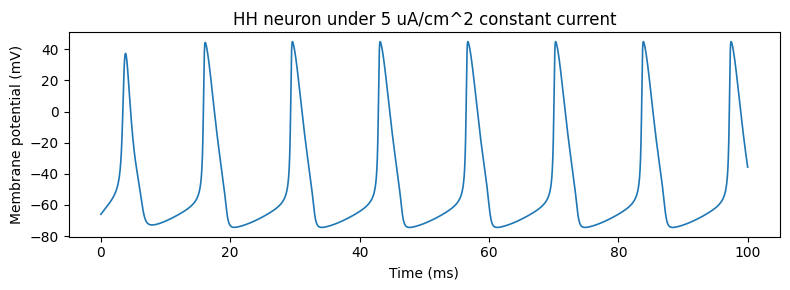

In [4]:
plt.figure(figsize=(8, 3))
plt.plot(times / u.ms, u.math.squeeze(vs) / u.mV, linewidth=1.2)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.title('HH neuron under 5 uA/cm^2 constant current')
plt.tight_layout()
plt.show()